# 10 — `reference`: re-referencing multi-channel signals

- `dsp.reference.common_average(x, dim=-2)` — z-scored CAR.
- `dsp.reference.random(x, dim=-2)` — random-channel reference.
- `dsp.reference.take_reference(x, tgt_indi, dim=-2)` — subtract
  specific channel(s).

All reduce along the channel axis (`dim=-2`).

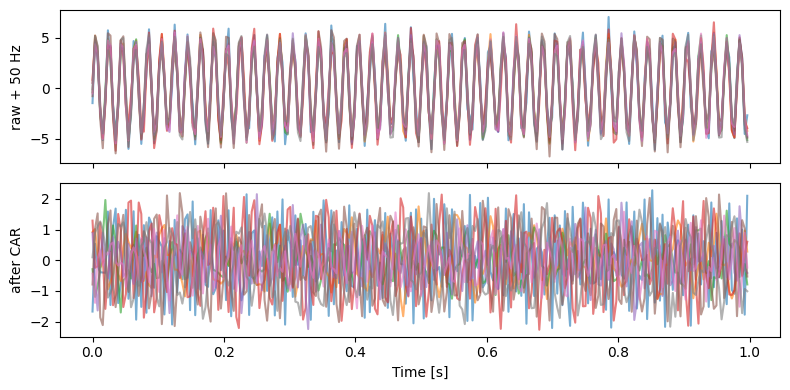

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import scitex_dsp as dsp
%matplotlib inline

xx, tt, fs = dsp.demo_sig(sig_type="periodic", batch_size=1, n_chs=8,
                          t_sec=1, fs=256)
artefact = (5 * np.sin(2 * np.pi * 50 * tt)).astype(np.float32)
xx = xx + artefact

yy = np.asarray(dsp.reference.common_average(xx))
fig, ax = plt.subplots(2, 1, figsize=(8, 4), sharex=True)
for c in range(xx.shape[1]):
    ax[0].plot(tt, xx[0, c], alpha=0.6)
    ax[1].plot(tt, yy[0, c], alpha=0.6)
ax[0].set_ylabel("raw + 50 Hz"); ax[1].set_ylabel("after CAR")
ax[-1].set_xlabel("Time [s]"); fig.tight_layout()
plt.show()
